In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_support_tickets_200k.csv")


In [3]:
df.head()


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 200000
Number of Columns: 30


In [5]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  object 
 13 

In [7]:
# summary statistics for numerical values 
df.describe()

,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,46.469040,30.377675,9.992115,3.001065,36.309180,120.539718,5.501365
std,57735.171256,16.754304,17.326224,6.053142,1.412273,20.654575,68.969143,2.875587
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.500000,1.000000,1.000000
25%,50000.750000,32.000000,15.000000,5.000000,2.000000,18.460000,60.810000,3.000000
50%,100000.500000,46.000000,30.000000,10.000000,3.000000,36.310000,120.450000,6.000000
75%,150000.250000,61.000000,45.000000,15.000000,4.000000,54.220000,180.260000,8.000000
max,200000.000000,75.000000,60.000000,20.000000,5.000000,72.000000,240.000000,10.000000


In [8]:
# Count missing values in each column
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language                           0
p

In [9]:
# To display only columns with missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

browser    40023
dtype: int64

In [10]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Display duplicate rows
df[df.duplicated()]

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment


In [12]:
print(df.columns)

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')


In [13]:
# this has done to add the column 'Type' in the dataset 
type_mapping = {
"Account Suspension": "Request",
"Performance Issue": "Problem",
"Subscription Cancellation": "Request",
"Feature Request": "Request",
"Payment Problem": "Incident",
"Security Concern": "Incident",
"Refund Request": "Request",
"Login Issue": "Incident",
"Bug Report": "Incident"
}

In [14]:
df["Type"] = df["category"].map(type_mapping)

In [15]:
df[["category", "Type"]].head(10)

,category,Type
0,Account Suspension,Request
1,Performance Issue,Problem
2,Performance Issue,Problem
3,Subscription Cancellation,Request
4,Feature Request,Request
5,Payment Problem,Incident
6,Security Concern,Incident
7,Subscription Cancellation,Request
8,Security Concern,Incident
9,Performance Issue,Problem


In [16]:
df[df["Type"].isna()]["category"].unique()

array(['Data Sync Issue'], dtype=object)

In [17]:
df.to_csv("customer_support_tickets_updated.csv", index=False)

In [18]:
import os

print(os.getcwd())

C:\Users\ratho\infosys project\note book


In [19]:
df["category"].unique()

array(['Account Suspension', 'Performance Issue',
       'Subscription Cancellation', 'Feature Request', 'Payment Problem',
       'Security Concern', 'Refund Request', 'Login Issue', 'Bug Report',
       'Data Sync Issue'], dtype=object)

In [20]:
df[["category", "Type"]].head(20)

,category,Type
0,Account Suspension,Request
1,Performance Issue,Problem
2,Performance Issue,Problem
3,Subscription Cancellation,Request
4,Feature Request,Request
5,Payment Problem,Incident
6,Security Concern,Incident
7,Subscription Cancellation,Request
8,Security Concern,Incident
9,Performance Issue,Problem


In [21]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment,Type
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business,Request
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business,Problem
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate,Problem
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate,Request
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate,Request


In [22]:
df.columns.tolist()

['ticket_id',
 'customer_name',
 'customer_email',
 'product',
 'category',
 'issue_description',
 'resolution_notes',
 'priority',
 'status',
 'channel',
 'region',
 'customer_age',
 'customer_gender',
 'subscription_type',
 'customer_tenure_months',
 'previous_tickets',
 'customer_satisfaction_score',
 'first_response_time_hours',
 'resolution_time_hours',
 'ticket_created_date',
 'ticket_resolved_date',
 'escalated',
 'sla_breached',
 'operating_system',
 'browser',
 'payment_method',
 'language',
 'preferred_contact_time',
 'issue_complexity_score',
 'customer_segment',
 'Type']

In [23]:
df["Type"].head(20)

0      Request
1      Problem
2      Problem
3      Request
4      Request
5     Incident
6     Incident
7      Request
8     Incident
9      Problem
10     Request
11    Incident
12     Request
13     Request
14     Request
15     Request
16     Request
17     Request
18     Request
19    Incident
Name: Type, dtype: object

In [24]:
df["Type"].value_counts()

Type
Request     80029
Incident    80020
Problem     20074
Name: count, dtype: int64

In [25]:
# Count tickets by type
Type_distribution = df['Type'].value_counts()

print(Type_distribution)

Type
Request     80029
Incident    80020
Problem     20074
Name: count, dtype: int64


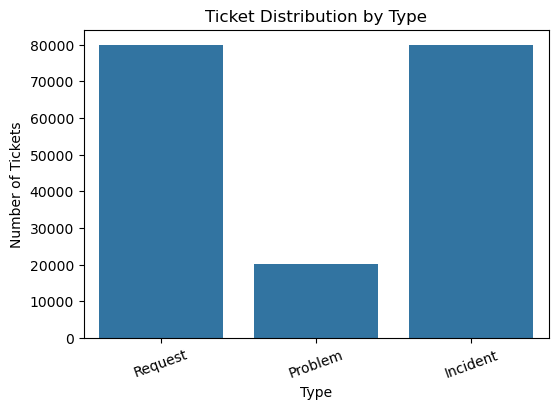

In [26]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Type')
plt.title('Ticket Distribution by Type')
plt.xlabel('Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=20)
plt.show()

In [27]:
# Count tickets by priority
priority_distribution = df['priority'].value_counts()

print(priority_distribution)

priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64


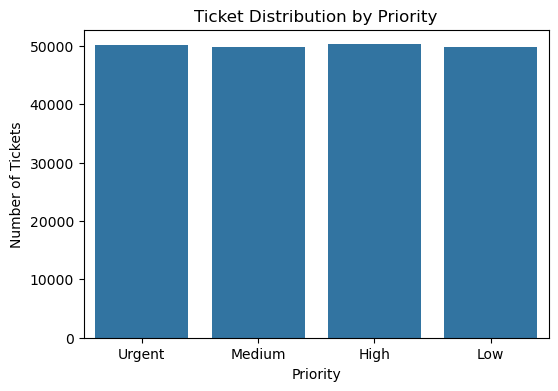

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='priority')
plt.title('Ticket Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.show()

In [29]:
# Count tickets by category
category_distribution = df['category'].value_counts()

print(category_distribution)

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64


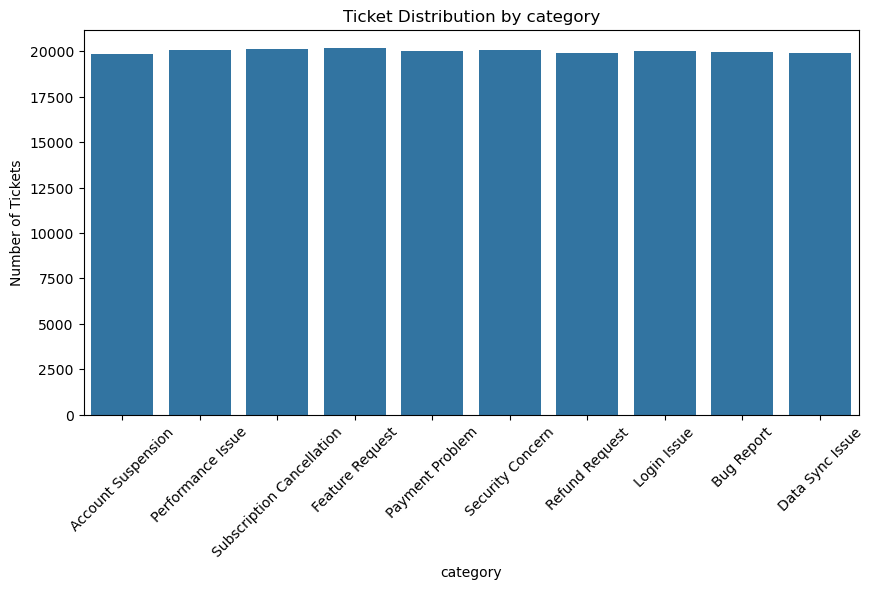

In [30]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='category')
plt.title('Ticket Distribution by category')
plt.xlabel('category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.show()

In [31]:
# Check missing values in all columns
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language                           0
p

In [32]:
text_columns = df.select_dtypes(include='object').columns
print(text_columns)

Index(['customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_gender', 'subscription_type',
       'ticket_created_date', 'ticket_resolved_date', 'escalated',
       'sla_breached', 'operating_system', 'browser', 'payment_method',
       'language', 'preferred_contact_time', 'customer_segment', 'Type'],
      dtype='object')


In [33]:
# Fill missing values in text columns
for col in text_columns:
    df[col] = df[col].fillna("Unknown")

In [34]:
df[text_columns].isnull().sum()

customer_name             0
customer_email            0
product                   0
category                  0
issue_description         0
resolution_notes          0
priority                  0
status                    0
channel                   0
region                    0
customer_gender           0
subscription_type         0
ticket_created_date       0
ticket_resolved_date      0
escalated                 0
sla_breached              0
operating_system          0
browser                   0
payment_method            0
language                  0
preferred_contact_time    0
customer_segment          0
Type                      0
dtype: int64

In [35]:
# Remove extra spaces
for col in text_columns:
    df[col] = df[col].str.strip()

In [36]:
# Convert to Title Case
for col in text_columns:
    df[col] = df[col].str.title()

In [37]:
df["category"].unique()

array(['Account Suspension', 'Performance Issue',
       'Subscription Cancellation', 'Feature Request', 'Payment Problem',
       'Security Concern', 'Refund Request', 'Login Issue', 'Bug Report',
       'Data Sync Issue'], dtype=object)

In [38]:
df["category"].value_counts()

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64

In [39]:
df["priority"].value_counts()

priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64

In [40]:
df["Type"].value_counts()

Type
Request     80029
Incident    80020
Problem     20074
Unknown     19877
Name: count, dtype: int64

In [41]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment,Type
0,1,Patricia Smith,Patricia.Smith760@Outlook.Com,Web Portal,Account Suspension,The Payment Was Deducted From My Bank Account ...,Data Synchronization Restored After Backend Se...,Urgent,Open,Email,...,No,Yes,Macos,Edge,Paypal,French,Afternoon,4,Small Business,Request
1,2,Patricia Williams,Patricia.Williams390@Gmail.Com,Mobile App,Performance Issue,I Found A Bug In The Latest Update Affecting R...,Provided Step-By-Step Troubleshooting Instruct...,Urgent,Closed,Email,...,Yes,Yes,Windows,Firefox,Paypal,English,Afternoon,2,Small Business,Problem
2,3,William Anderson,William.Anderson651@Outlook.Com,Web Portal,Performance Issue,The Application Crashes Whenever I Try To Uplo...,Provided Step-By-Step Troubleshooting Instruct...,Medium,Closed,Chat,...,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate,Problem
3,4,David Miller,David.Miller672@Icloud.Com,Payment Gateway,Subscription Cancellation,My Subscription Was Cancelled Without My Reque...,Provided Step-By-Step Troubleshooting Instruct...,Medium,Closed,Social Media,...,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate,Request
4,5,Robert Gonzalez,Robert.Gonzalez391@Hotmail.Com,Web Portal,Feature Request,The System Is Not Syncing Data Across Devices ...,We Have Reset The Account Credentials And Advi...,High,Pending Customer,Email,...,Yes,No,Linux,Unknown,Debit Card,Spanish,Evening,3,Corporate,Request


In [46]:
# Create resolution duration 
df["ticket_created_date"] = pd.to_datetime(df["ticket_created_date"])

df["ticket_resolved_date"] = pd.to_datetime(df["ticket_resolved_date"])
df["Resolution_Duration"] = (
    df["ticket_resolved_date"] -
    df["ticket_created_date"]
).dt.days
df[["ticket_created_date",
    "ticket_resolved_date",
    "Resolution_Duration"]].head()

,ticket_created_date,ticket_resolved_date,Resolution_Duration
0,2023-05-17,2023-05-20,3
1,2024-01-06,2024-01-19,13
2,2022-11-30,2022-12-05,5
3,2024-03-21,2024-04-04,14
4,2024-08-16,2024-08-24,8


In [48]:
# Create priority score 
priority_mapping = {
    "Low":1,
    "Medium":2,
    "High":3,
    "Urgent":4
}

df["Priority_Score"] = df["priority"].map(priority_mapping)
df[["priority","Priority_Score"]].head()

,priority,Priority_Score
0,Urgent,4
1,Urgent,4
2,Medium,2
3,Medium,2
4,High,3


In [49]:
df.to_csv("customer_support_tickets_cleaned.csv", index=False)

In [53]:
# Verify the new features 
df[['Type', 'Resolution_Duration', 'Priority_Score']].head()

,Type,Resolution_Duration,Priority_Score
0,Request,3,4
1,Problem,13,4
2,Problem,5,2
3,Request,14,2
4,Request,8,3
